In [1]:
# Install libraries (if needed)
!pip install pandas matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = {
    'Price':[250,300,180,500,220,270,320,450,210,260],
    'Area':[1200,1400,900,2200,1100,1300,1500,2100,1000,1250],
    'Bedrooms':[2,3,2,4,2,3,3,4,2,3],
    'Distance_from_City':[15,12,25,5,20,18,10,6,22,16],
    'Property_Age':[15,8,20,3,18,12,7,5,19,10],
    'Months_On_Market':[8,2,12,1,10,7,3,2,11,6]
}

df = pd.DataFrame(data)


In [3]:
X = df.drop('Months_On_Market', axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA()

principal_components = pca.fit_transform(X_scaled)

print("Explained Variance Ratio")
print(pca.explained_variance_ratio_)


Explained Variance Ratio
[9.44262661e-01 2.86582780e-02 2.57406216e-02 1.24136639e-03
 9.70727975e-05]


In [4]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(len(X.columns))],
    index=X.columns
)

print("\nPCA Loadings")
print(loadings)


PCA Loadings
                         PC1       PC2       PC3       PC4       PC5
Price               0.451164  0.506441 -0.013049  0.583087 -0.446997
Area                0.452202  0.487014  0.005651 -0.227043  0.711864
Bedrooms            0.442623 -0.181654  0.733909 -0.387850 -0.286421
Distance_from_City -0.445231  0.158431  0.677637  0.465467  0.317516
Property_Age       -0.444768  0.669504  0.044534 -0.491297 -0.332550


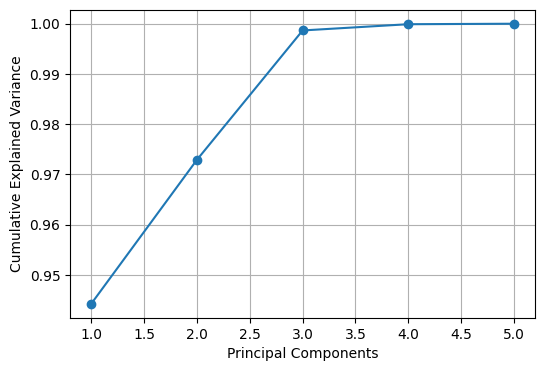

In [5]:
plt.figure(figsize=(6,4))
plt.plot(range(1,len(X.columns)+1),
         np.cumsum(pca.explained_variance_ratio_),
         marker='o')
plt.xlabel("Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid(True)
plt.show()